<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/VGG16_and_Fine_tunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.utils import get_file
import json
import numpy as np
import matplotlib.pyplot as plt

# Download Imagenet class

In [2]:
class_index_path = 'https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json'

# load it

In [3]:
fpath = get_file("imagenet_class_index.json",class_index_path)
with open(fpath) as f:
  class_index = json.load(f)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


#Print how many classes and show a few samples

In [4]:
print("Total Classes:", len(class_index))
list(class_index.items())[:5]

Total Classes: 1000


[('0', ['n01440764', 'tench']),
 ('1', ['n01443537', 'goldfish']),
 ('2', ['n01484850', 'great_white_shark']),
 ('3', ['n01491361', 'tiger_shark']),
 ('4', ['n01494475', 'hammerhead'])]

In [5]:
for key,values in class_index.items():
  print(values[1])

tench
goldfish
great_white_shark
tiger_shark
hammerhead
electric_ray
stingray
cock
hen
ostrich
brambling
goldfinch
house_finch
junco
indigo_bunting
robin
bulbul
jay
magpie
chickadee
water_ouzel
kite
bald_eagle
vulture
great_grey_owl
European_fire_salamander
common_newt
eft
spotted_salamander
axolotl
bullfrog
tree_frog
tailed_frog
loggerhead
leatherback_turtle
mud_turtle
terrapin
box_turtle
banded_gecko
common_iguana
American_chameleon
whiptail
agama
frilled_lizard
alligator_lizard
Gila_monster
green_lizard
African_chameleon
Komodo_dragon
African_crocodile
American_alligator
triceratops
thunder_snake
ringneck_snake
hognose_snake
green_snake
king_snake
garter_snake
water_snake
vine_snake
night_snake
boa_constrictor
rock_python
Indian_cobra
green_mamba
sea_snake
horned_viper
diamondback
sidewinder
trilobite
harvestman
scorpion
black_and_gold_garden_spider
barn_spider
garden_spider
black_widow
tarantula
wolf_spider
tick
centipede
black_grouse
ptarmigan
ruffed_grouse
prairie_chicken
peacock

In [6]:
pretrained_model = VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 31s 0us/step


In [7]:
pretrained_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

#General predictions - using the pretrained model

In [8]:
from google.colab import files
uploaded = files.upload()

Saving cheetah.jpg to cheetah.jpg


In [9]:
from tensorflow.keras.preprocessing.image import load_img

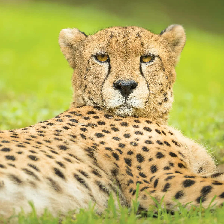

In [10]:
image_for_class = load_img("cheetah.jpg",target_size = (224,224))
image_for_class

In [11]:
image_for_class = np.array(image_for_class)
image_for_class = preprocess_input(image_for_class)
image_for_class = image_for_class.reshape(1,224,224,3)

In [12]:
preds = pretrained_model.predict(image_for_class)
decode = decode_predictions(preds,top = 3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 896ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [13]:
label = decode[0][0][1]
confidence = decode[0][0][2]
print(f"Predicted:{label}({confidence: .2f}% confidence)")

Predicted:cheetah( 1.00% confidence)


#Finetunning the model

finetuning the model to predict Cars/planes

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [15]:
pretrained_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
baseline_model = Sequential()

for layer in pretrained_model.layers[:-1]:
  layer.trainable = False
  baseline_model.add(layer)

baseline_model.add(Dense(1,activation = "sigmoid"))

In [17]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,264,641 (512.18 MB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 134,260,544 (512.16 MB)

In [18]:
from google.colab import files
uploaded = files.upload()

Saving Cars.zip to Cars.zip
Saving flight.zip to flight.zip


In [21]:
import zipfile

with zipfile.ZipFile("/content/Cars.zip","r") as zip_ref:
  zip_ref.extractall("/content")

with zipfile.ZipFile("/content/flight.zip","r") as zip_ref:
  zip_ref.extractall("/content")

In [24]:
# os → Used for interacting with the operating system (creating folders, checking if files/folders exist, etc.).
#shutil → Used for high-level file operations such as copying and moving files/folders.
# makedirs() creates a directory.
#"dataset" is the folder name.
#exist_ok=True means:
#If the folder doesn't exist → create it.
#If the folder already exists → don't raise an error.

import os
import shutil

os.makedirs("dataset",exist_ok = True)

if not os.path.exists("dataset/Cars"):
  shutil.move("Cars","dataset/Cars")

if not os.path.exists("dataset/flight"):
  shutil.move("flight","dataset/flight")

In [25]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    image_size = (224,224),
    batch_size = 32,
    shuffle = True
)

Found 21 files belonging to 2 classes.


In [26]:
print(dataset.class_names)

['Cars', 'flight']


#Load Dataset

In [27]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split = 0.2,
    subset = "training",
    seed = 42,
    image_size = (224,224),
    batch_size = 32
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split = 0.2,
    subset = "validation",
    seed = 42,
    image_size = (224,224),
    batch_size = 32
)

Found 21 files belonging to 2 classes.
Using 17 files for training.
Found 21 files belonging to 2 classes.
Using 4 files for validation.


In [28]:
print(train_dataset.class_names)

['Cars', 'flight']


In [29]:
train_dataset = train_dataset.map(
    lambda x,y: (preprocess_input(x),y)
)
val_dataset = val_dataset.map(
    lambda x,y: (preprocess_input(x),y)
)

# compile Model

In [30]:
baseline_model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

#Train Feature Extractor

In [31]:
history = baseline_model.fit(train_dataset,
                             validation_data = val_dataset,
                             epochs = 5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.8235 - loss: 0.5717 - val_accuracy: 1.0000 - val_loss: 0.2434
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.9412 - loss: 0.1632 - val_accuracy: 1.0000 - val_loss: 0.0779
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0586 - val_accuracy: 1.0000 - val_loss: 0.0345
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0265 - val_accuracy: 1.0000 - val_loss: 0.0180
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 0.0105


#Recompile with small Learning Rate

In [32]:
from tensorflow.keras.optimizers import Adam
baseline_model.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

#Fine-Tune

In [34]:
history_ft = baseline_model.fit(
    train_dataset,validation_data = val_dataset,
    epochs = 5
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0099
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 0.0096
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0094
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0091


# Plot training curves

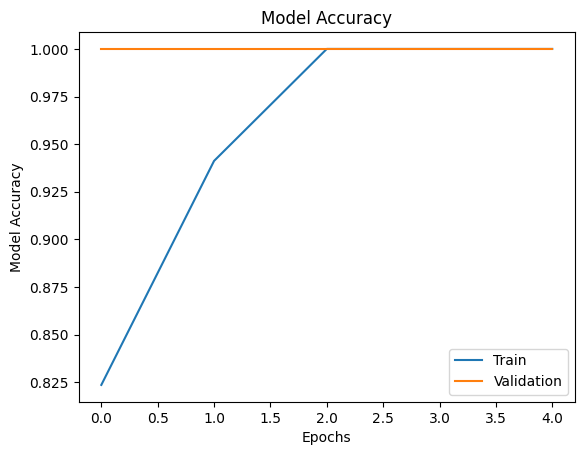

In [35]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()

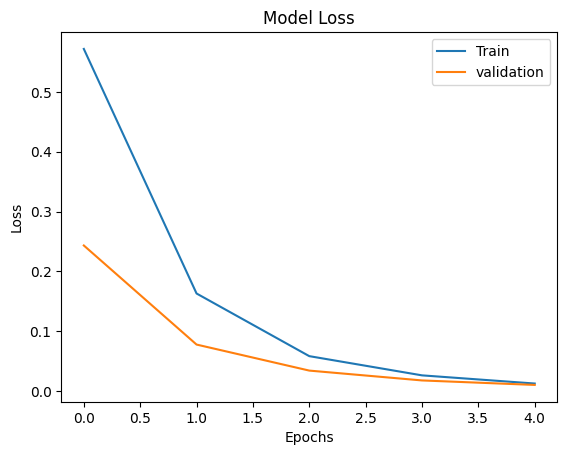

In [37]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train","validation"])
plt.show()